In [1]:
# ==============================================================================
# PIPELINE 7: Supervised Learning - Classification (Predicting Market Failure)
# ==============================================================================
import pandas as pd

from src.training.supervised import prepare_supervised_data, tune_supervised_model
from src.training.evaluation import evaluate_classification
from src.training.visualization import plot_confusion_matrix_heatmap

pd.set_option('display.max_columns', None)

print("Loading Golden Dataset from Pipeline 5...")
df_ml = pd.read_parquet("data/prepared/ted_prepared.parquet")

Loading Golden Dataset from Pipeline 5...


In [2]:
# ------------------------------------------------------------------------------
# STEP 1: Feature Setup & Strict Group Data Splitting
# ------------------------------------------------------------------------------
# Target Definition: Market Failure (1 = Single Bidding or no bids, 0 = Healthy Competition)
df_ml['TARGET_MARKET_FAILURE'] = (df_ml['NUMBER_OF_TENDERS'] <= 1).astype(int)

# Categorical and Numeric Features
categorical_cols = ['ISO_COUNTRY_CODE', 'CAE_TYPE', 'MAIN_ACTIVITY', 'TOP_TYPE', 'CPV', 'ID_TYPE']

# CRITICAL: We MUST drop 'NUMBER_OF_TENDERS' from numeric_cols to prevent trivial target leakage!
numeric_cols = ['TARGET_AWARD_VALUE_EUR', 'LOT_AWARD_VALUE_EUR', 'LOTS_NUMBER', 'DURATION', 'PREPARATION_DAYS', 'NUTS_REGION_COUNT']

X_train, X_test, y_train, y_test, groups_train = prepare_supervised_data(
    df=df_ml,
    target_col='TARGET_MARKET_FAILURE',
    group_col='ID_NOTICE',
    feature_cols=categorical_cols + numeric_cols,
    test_size=0.2
)


Preparing data for supervised learning. Target: 'TARGET_MARKET_FAILURE'
 -> Train shape: (1937201, 12), Test shape: (488326, 12)



Tuning Hyperparameters for 'LINEAR' (CLF)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


 -> Optimization complete. Best parameters: {'model__C': 1.0}

Evaluating Logistic Regression on unseen Test Set...

--- Classification Results ---
Balanced Acc: 0.6926
F1-Score:     0.7914
Precision:    0.7607
Recall:       0.8247


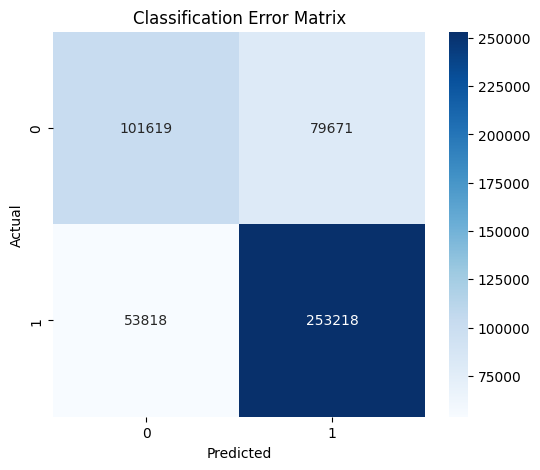

In [3]:
# ------------------------------------------------------------------------------
# STEP 2: Logistic Regression (Linear Baseline)
# ------------------------------------------------------------------------------
model_logreg = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, 
    model_name='linear', task='clf', n_iter=10
)

print("\nEvaluating Logistic Regression on unseen Test Set...")
preds_logreg = model_logreg.predict(X_test)
eval_logreg = evaluate_classification(y_test, preds_logreg)
plot_confusion_matrix_heatmap(y_test, preds_logreg)


Tuning Hyperparameters for 'DT' (CLF)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


 -> Optimization complete. Best parameters: {'model__min_samples_leaf': 1, 'model__max_depth': 15}

Evaluating Decision Tree on unseen Test Set...

--- Classification Results ---
Balanced Acc: 0.7371
F1-Score:     0.8080
Precision:    0.8024
Recall:       0.8136


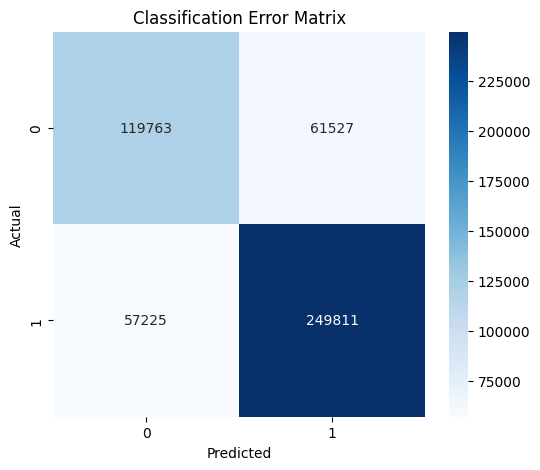

In [4]:
# ------------------------------------------------------------------------------
# STEP 3: Decision Tree (High Interpretability)
# ------------------------------------------------------------------------------
model_dt = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, 
    model_name='dt', task='clf', n_iter=20
)

print("\nEvaluating Decision Tree on unseen Test Set...")
preds_dt = model_dt.predict(X_test)
eval_dt = evaluate_classification(y_test, preds_dt)
plot_confusion_matrix_heatmap(y_test, preds_dt)


Tuning Hyperparameters for 'XGBOOST' (CLF)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/home/msuess/Documents/KIDS/Project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


 -> Optimization complete. Best parameters: {'model__n_estimators': 500, 'model__max_depth': 9, 'model__learning_rate': 0.05}

Evaluating XGBoost on unseen Test Set...

--- Classification Results ---
Balanced Acc: 0.7585
F1-Score:     0.8235
Precision:    0.8182
Recall:       0.8289


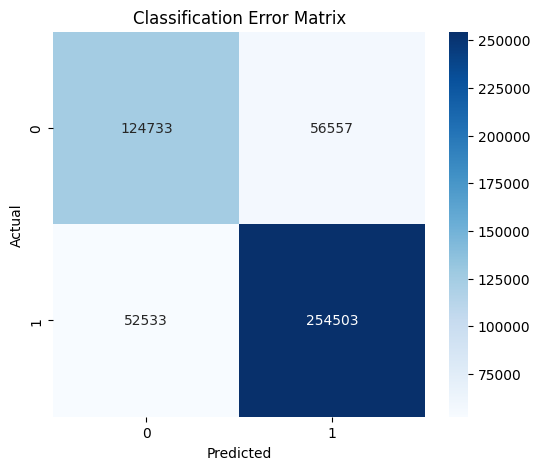

In [5]:
# ------------------------------------------------------------------------------
# STEP 4: XGBoost (Advanced Ensemble Learning)
# ------------------------------------------------------------------------------
model_xgb_clf = tune_supervised_model(
    X_train, y_train, groups_train, categorical_cols, numeric_cols, 
    model_name='xgboost', task='clf', n_iter=20
)

print("\nEvaluating XGBoost on unseen Test Set...")
preds_xgb_clf = model_xgb_clf.predict(X_test)
eval_xgb_clf = evaluate_classification(y_test, preds_xgb_clf)
plot_confusion_matrix_heatmap(y_test, preds_xgb_clf)